In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

In [42]:
df=pd.read_csv("C:/Users/zinan/OneDrive/Documents/loan_approval.csv")
df

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False
...,...,...,...,...,...,...,...,...
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False


In [43]:
df.shape

(2000, 8)

In [44]:
df.columns

Index(['name', 'city', 'income', 'credit_score', 'loan_amount',
       'years_employed', 'points', 'loan_approved'],
      dtype='object')

In [45]:
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [46]:
df.tail()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
1995,James Schaefer,Robertton,92163,770,12251,13,85.0,True
1996,Diana Lin,New Frank,38799,635,48259,17,40.0,False
1997,Brandon Meyer,East Haley,41957,763,16752,5,60.0,True
1998,Jason Price,Adamland,139022,360,24031,35,55.0,False
1999,Nicole Brown,New Nathantown,41188,482,31397,6,20.0,False


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2000 non-null   object 
 1   city            2000 non-null   object 
 2   income          2000 non-null   int64  
 3   credit_score    2000 non-null   int64  
 4   loan_amount     2000 non-null   int64  
 5   years_employed  2000 non-null   int64  
 6   points          2000 non-null   float64
 7   loan_approved   2000 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(2)
memory usage: 111.5+ KB


In [48]:
df.describe(include='all')

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
count,2000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000
unique,2000,1882,NaN,NaN,NaN,NaN,NaN,2
top,Allison Hill,North Joseph,NaN,NaN,NaN,NaN,NaN,False
freq,1,4,NaN,NaN,NaN,NaN,NaN,1121
mean,NaN,NaN,90585.977000,573.946000,25308.503000,20.441000,56.680000,NaN
std,NaN,NaN,34487.874907,160.564945,14207.320147,11.777813,18.638033,NaN
min,NaN,NaN,30053.000000,300.000000,1022.000000,0.000000,10.000000,NaN
25%,NaN,NaN,61296.250000,433.000000,12748.750000,10.000000,45.000000,NaN
50%,NaN,NaN,90387.500000,576.000000,25661.500000,21.000000,55.000000,NaN
75%,NaN,NaN,120099.750000,715.000000,37380.500000,31.000000,70.000000,NaN


In [49]:
df.isna().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.dtypes

name               object
city               object
income              int64
credit_score        int64
loan_amount         int64
years_employed      int64
points            float64
loan_approved        bool
dtype: object

In [52]:
encode=LabelEncoder()
df['name']=encode.fit_transform(df['name'])
df['city']=encode.fit_transform(df['city'])

In [53]:
df.dtypes

name                int64
city                int64
income              int64
credit_score        int64
loan_amount         int64
years_employed      int64
points            float64
loan_approved        bool
dtype: object

In [54]:
df1=df['loan_approved'].value_counts()
df1

loan_approved
False    1121
True      879
Name: count, dtype: int64

<Axes: xlabel='loan_approved', ylabel='count'>

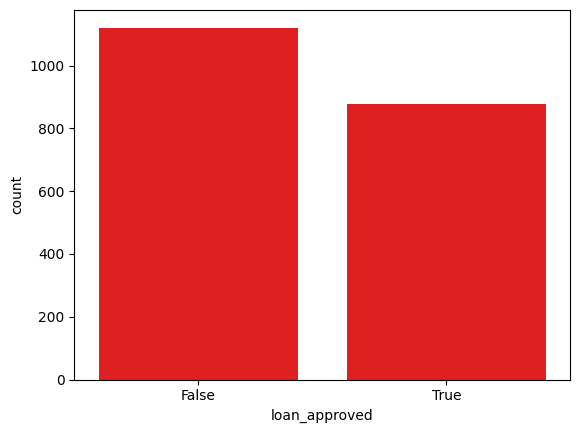

In [55]:
sns.countplot(x='loan_approved',data=df,color='r')

Text(0.5, 1.0, 'loan approval count')

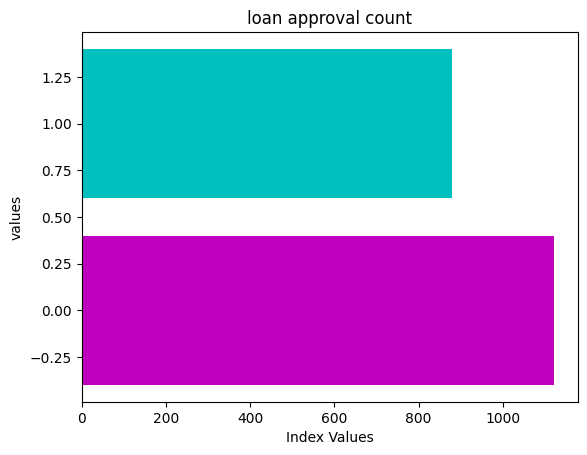

In [56]:
co=['m','c']
plt.barh(df1.index,df1.values,color=co)
plt.xlabel('Index Values')
plt.ylabel('values')
plt.title('loan approval count')

Text(0.5, 1.0, 'Pie_chart_LOAN')

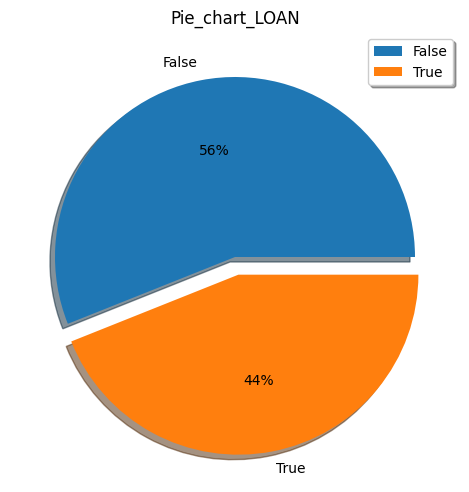

In [57]:
ex=[0,0.1]
plt.pie(df1.values,labels=df1.index,explode=ex,shadow=True,autopct="%2.f%%")
plt.legend(loc='upper right',shadow=True)
plt.tight_layout()
plt.title('Pie_chart_LOAN')


<Axes: >

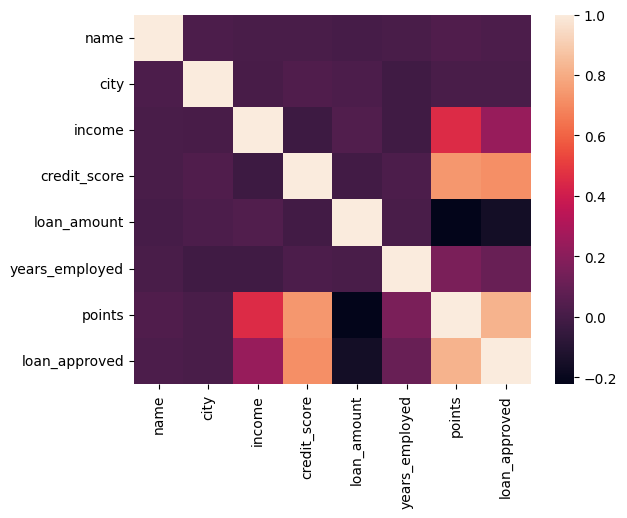

In [58]:
sns.heatmap(df.corr(numeric_only=True))

Text(0.5, 1.0, 'loan approval count')

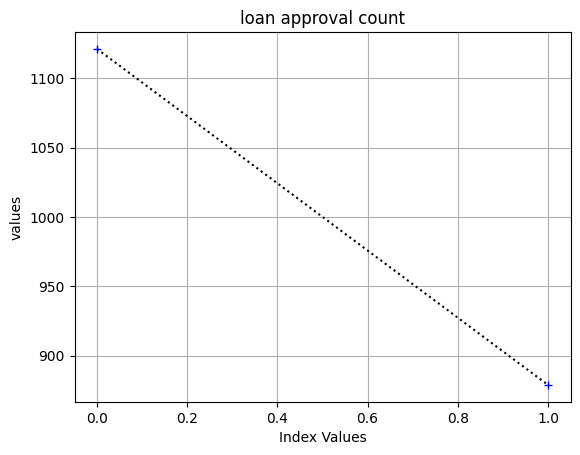

In [59]:
plt.plot(df1.index,df1.values,color='k',marker='+',ms=6,mfc='g',mec='b',linestyle='dotted')
plt.grid()
plt.xlabel('Index Values')
plt.ylabel('values')
plt.title('loan approval count')

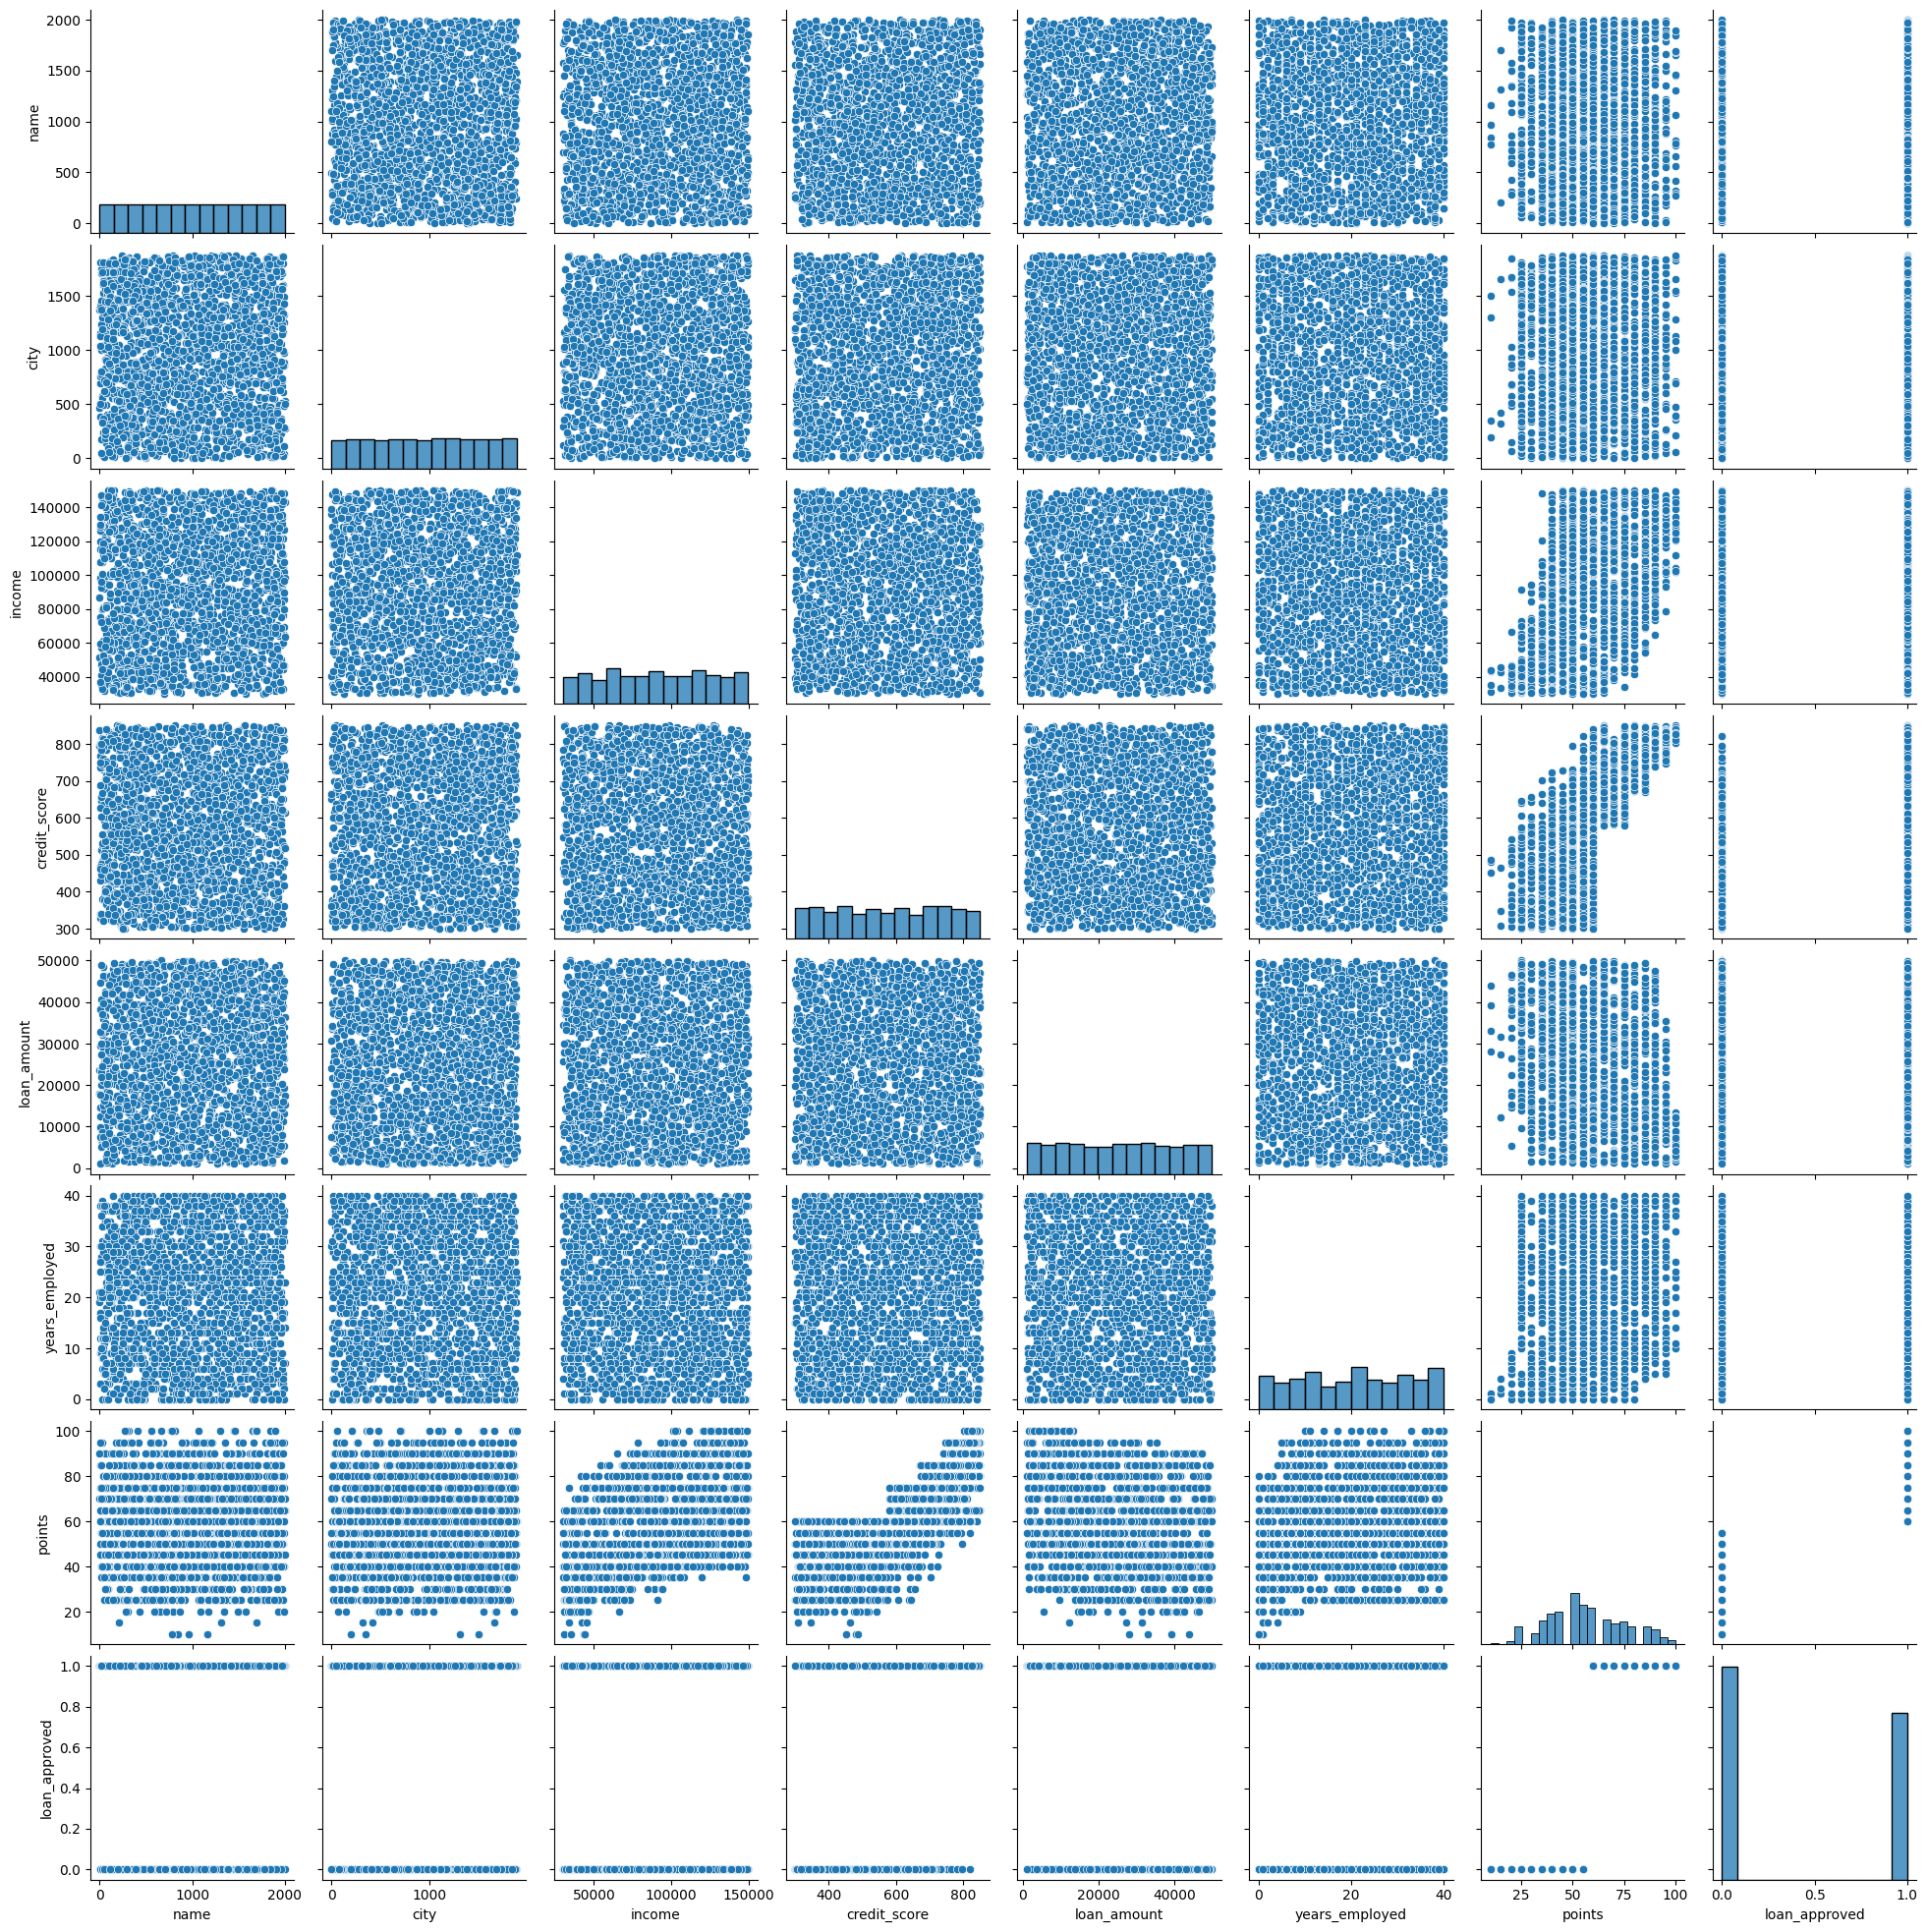

In [60]:
sns.pairplot(df)

In [61]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
x

array([[4.60000e+01, 3.26000e+02, 1.13810e+05, ..., 3.96980e+04,
        2.70000e+01, 5.00000e+01],
       [2.18000e+02, 9.89000e+02, 4.45920e+04, ..., 1.54460e+04,
        2.80000e+01, 5.50000e+01],
       [1.60500e+03, 7.63000e+02, 3.32780e+04, ..., 1.11890e+04,
        1.30000e+01, 4.50000e+01],
       ...,
       [2.21000e+02, 3.08000e+02, 4.19570e+04, ..., 1.67520e+04,
        5.00000e+00, 6.00000e+01],
       [8.04000e+02, 2.00000e+00, 1.39022e+05, ..., 2.40310e+04,
        3.50000e+01, 5.50000e+01],
       [1.49600e+03, 1.03200e+03, 4.11880e+04, ..., 3.13970e+04,
        6.00000e+00, 2.00000e+01]], shape=(2000, 7))

In [62]:
y

array([False, False, False, ...,  True, False, False], shape=(2000,))

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)
x_train

array([[1.6400e+03, 3.8600e+02, 6.3092e+04, ..., 2.3665e+04, 4.0000e+00,
        3.0000e+01],
       [1.8900e+02, 3.9600e+02, 6.6421e+04, ..., 4.6692e+04, 1.8000e+01,
        6.0000e+01],
       [7.0000e+00, 1.3910e+03, 7.5236e+04, ..., 1.7608e+04, 3.8000e+01,
        8.5000e+01],
       ...,
       [1.1670e+03, 9.4500e+02, 8.5872e+04, ..., 3.1259e+04, 3.5000e+01,
        7.0000e+01],
       [1.7700e+03, 1.6030e+03, 4.4662e+04, ..., 4.6990e+03, 8.0000e+00,
        3.0000e+01],
       [8.1000e+01, 1.5560e+03, 7.2245e+04, ..., 2.5358e+04, 3.0000e+00,
        5.5000e+01]], shape=(1400, 7))

In [64]:
x_test

array([[8.14000e+02, 1.86100e+03, 1.27248e+05, ..., 1.25260e+04,
        1.00000e+01, 1.00000e+02],
       [1.10400e+03, 1.16000e+03, 7.78230e+04, ..., 4.34990e+04,
        3.60000e+01, 4.00000e+01],
       [5.00000e+00, 3.89000e+02, 5.94660e+04, ..., 4.45710e+04,
        3.00000e+01, 6.00000e+01],
       ...,
       [8.60000e+01, 1.14500e+03, 1.20957e+05, ..., 1.71420e+04,
        3.50000e+01, 5.50000e+01],
       [1.19300e+03, 5.97000e+02, 1.05470e+05, ..., 2.60200e+04,
        1.00000e+01, 5.50000e+01],
       [1.81100e+03, 1.84700e+03, 1.27609e+05, ..., 4.64790e+04,
        1.30000e+01, 5.00000e+01]], shape=(600, 7))

In [65]:
y_train

array([False,  True,  True, ...,  True, False, False], shape=(1400,))

In [66]:
y_test

array([ True, False,  True, False,  True,  True,  True, False, False,
        True, False,  True, False, False,  True, False, False,  True,
       False,  True, False,  True, False, False,  True, False,  True,
        True, False,  True,  True, False, False,  True, False, False,
        True, False,  True,  True,  True,  True,  True, False, False,
       False,  True,  True, False, False, False,  True,  True,  True,
       False, False, False,  True,  True, False, False, False, False,
       False, False,  True, False,  True,  True,  True, False, False,
        True,  True, False, False, False, False, False, False,  True,
       False,  True, False,  True,  True, False, False,  True, False,
        True, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True, False,  True, False,
        True,  True, False, False, False, False, False, False, False,
        True,  True,

In [67]:
scalar=StandardScaler()
scalar.fit(x_train)
x_train=scalar.transform(x_train)
x_test=scalar.transform(x_test)
x_train

array([[ 1.11213827, -1.02963588, -0.78917607, ..., -0.09616893,
        -1.37790565, -1.41044772],
       [-1.38964758, -1.01137466, -0.69341417, ...,  1.51807232,
        -0.19104778,  0.18585528],
       [-1.70344843,  0.80561757, -0.43984218, ..., -0.5207774 ,
         1.50446345,  1.51610778],
       ...,
       [ 0.29660091, -0.00883322, -0.13388737, ...,  0.43618648,
         1.25013677,  0.71795628],
       [ 1.33628173,  1.19275561, -1.31933282, ..., -1.42572551,
        -1.0388034 , -1.41044772],
       [-1.57585907,  1.10692784, -0.52588118, ...,  0.02251394,
        -1.46268121, -0.08019522]], shape=(1400, 7))

In [68]:
x_test

array([[-0.31203479,  1.6638953 ,  1.05633324, ..., -0.87703631,
        -0.86925228,  2.31425928],
       [ 0.18797754,  0.38378319, -0.36542463, ...,  1.29423629,
         1.33491233, -0.87834672],
       [-1.70689679, -1.02415752, -0.89348146, ...,  1.36938575,
         0.82625896,  0.18585528],
       ...,
       [-1.56723817,  0.35639135,  0.87536655, ..., -0.55344498,
         1.25013677, -0.08019522],
       [ 0.34142961, -0.64432396,  0.42986803, ...,  0.06892154,
        -0.86925228, -0.08019522],
       [ 1.40697313,  1.63832958,  1.06671775, ...,  1.50314057,
        -0.61492559, -0.34624572]], shape=(600, 7))

In [69]:
model=SVC()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([ True, False,  True, False,  True,  True,  True, False, False,
        True, False,  True, False, False,  True, False, False,  True,
       False,  True, False,  True, False, False,  True, False,  True,
        True, False,  True,  True, False, False,  True, False, False,
        True, False,  True,  True,  True,  True,  True, False, False,
       False,  True,  True, False, False, False,  True,  True,  True,
       False, False, False,  True,  True, False, False, False, False,
        True, False,  True, False,  True,  True,  True, False, False,
        True,  True, False, False, False, False, False, False,  True,
       False,  True, False,  True,  True, False, False,  True, False,
        True, False, False,  True, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False,  True,  True,  True, False,  True, False,
        True,  True, False, False, False, False, False, False, False,
        True,  True,

In [70]:
y_test

array([ True, False,  True, False,  True,  True,  True, False, False,
        True, False,  True, False, False,  True, False, False,  True,
       False,  True, False,  True, False, False,  True, False,  True,
        True, False,  True,  True, False, False,  True, False, False,
        True, False,  True,  True,  True,  True,  True, False, False,
       False,  True,  True, False, False, False,  True,  True,  True,
       False, False, False,  True,  True, False, False, False, False,
       False, False,  True, False,  True,  True,  True, False, False,
        True,  True, False, False, False, False, False, False,  True,
       False,  True, False,  True,  True, False, False,  True, False,
        True, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True,  True,  True, False,  True, False,
        True,  True, False, False, False, False, False, False, False,
        True,  True,

In [71]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[329,   5],
       [  1, 265]])

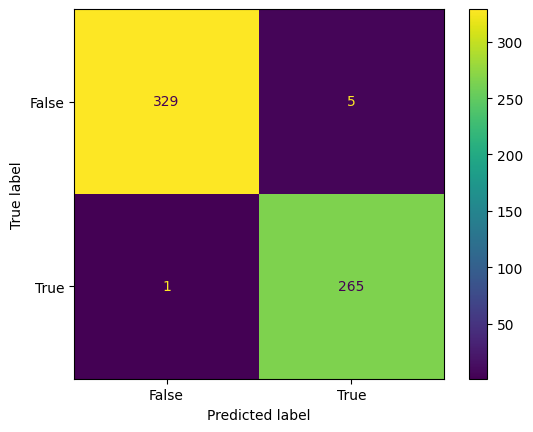

In [72]:
lab=[False,True]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [74]:
score=accuracy_score(y_test,y_pred)*100
score

99.0

In [75]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

       False       1.00      0.99      0.99       334
        True       0.98      1.00      0.99       266

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

